# MCDA Ranking Methods Available in VISTA by Default

This notebook provides an overview of ranking methods from the pyDecision library that are already registered in *mcda-vista*.
We explore the method registry, generate baseline VISTA maps with default parameters,
and compare methods within their natural families.

In [1]:
%matplotlib inline

from mcda_vista import generate_vista, plot_vista, plot_vista_comparison, VistaResult
from mcda_vista.methods import list_methods, get_method

## 1. List All Methods

`list_methods()` returns sorted names of every registered method.
For each one we can retrieve a `MethodAdapter` that exposes
`.display_name` and `.default_params()`.

In [2]:
method_names = list_methods()
print(f"Total methods: {len(method_names)}\n")

for name in method_names:
    adapter = get_method(name)
    params = adapter.default_params()
    params_str = ", ".join(f"{k}={v!r}" for k, v in params.items()) if params else "(none)"
    print(f"  {adapter.display_name:<18s} [{name}]  —  {params_str}")

Total methods: 16

  ASSESS             [assess]  —  k=5, form='L', delta=0.1
  Borda              [borda]  —  (none)
  ELECTRE III        [electre_iii]  —  q=0.1, p=0.2, v=1.0, alpha=-0.15, beta=0.3
  ELECTRE IIIc       [electre_iiic]  —  q=0.1, p=0.2, v=1.0, lamb=0.6
  E-TOPSIS           [etopsis]  —  aggregation='R', epsilon=1.0, delta=0.1
  MACBETH            [macbeth]  —  delta=0.1
  ORESTE             [oreste]  —  alpha=0.4
  PROMETHEE I        [promethee_i]  —  f='t4', q=0.1, p=0.2, s=0.0
  PROMETHEE II       [promethee_ii]  —  f='t4', q=0.1, p=0.2, s=0.0, delta=0.1
  PROMETHEE III      [promethee_iii]  —  f='t4', q=0.1, p=0.2, s=0.0, lmbd=0.1
  REGIME             [regime]  —  (none)
  SAW                [saw]  —  delta=0.1
  SPOTIS             [spotis]  —  delta=0.1
  TOPSIS             [topsis]  —  delta=0.1
  UTA                [uta]  —  k=5, form='L', delta=0.1
  VIKOR              [vikor]  —  v=0.5


## 2. Generate Baseline VISTA Maps for All Methods

We use `resolution=51` (51 × 51 = 2 601 grid points) for fast generation
while still producing clear maps. Every method runs with its own default parameters.

In [3]:
RESOLUTION = 51

results = []
for i, name in enumerate(method_names, 1):
    adapter = get_method(name)
    print(f"[{i:2d}/{len(method_names)}] Generating {adapter.display_name} ...", end=" ")
    result = generate_vista(name, resolution=RESOLUTION, progress=False, **adapter.default_params())
    results.append(result)
    elapsed = result.metadata.get("elapsed_seconds", 0)
    print(f"done ({elapsed:.1f}s)")

print(f"\nAll {len(results)} methods generated.")

[ 1/16] Generating ASSESS ... done (0.1s)
[ 2/16] Generating Borda ... done (0.1s)
[ 3/16] Generating ELECTRE III ... done (0.5s)
[ 4/16] Generating ELECTRE IIIc ... done (0.5s)
[ 5/16] Generating E-TOPSIS ... done (0.2s)
[ 6/16] Generating MACBETH ... done (0.1s)
[ 7/16] Generating ORESTE ... done (0.7s)
[ 8/16] Generating PROMETHEE I ... done (0.1s)
[ 9/16] Generating PROMETHEE II ... done (0.1s)
[10/16] Generating PROMETHEE III ... done (0.1s)
[11/16] Generating REGIME ... done (0.0s)
[12/16] Generating SAW ... done (0.1s)
[13/16] Generating SPOTIS ... done (0.1s)
[14/16] Generating TOPSIS ... done (0.2s)
[15/16] Generating UTA ... done (0.1s)
[16/16] Generating VIKOR ... done (0.3s)

All 16 methods generated.


## 3. Side-by-Side Comparison

This section uses the `plot_vista_comparison` to plot multiple vistas side by side.

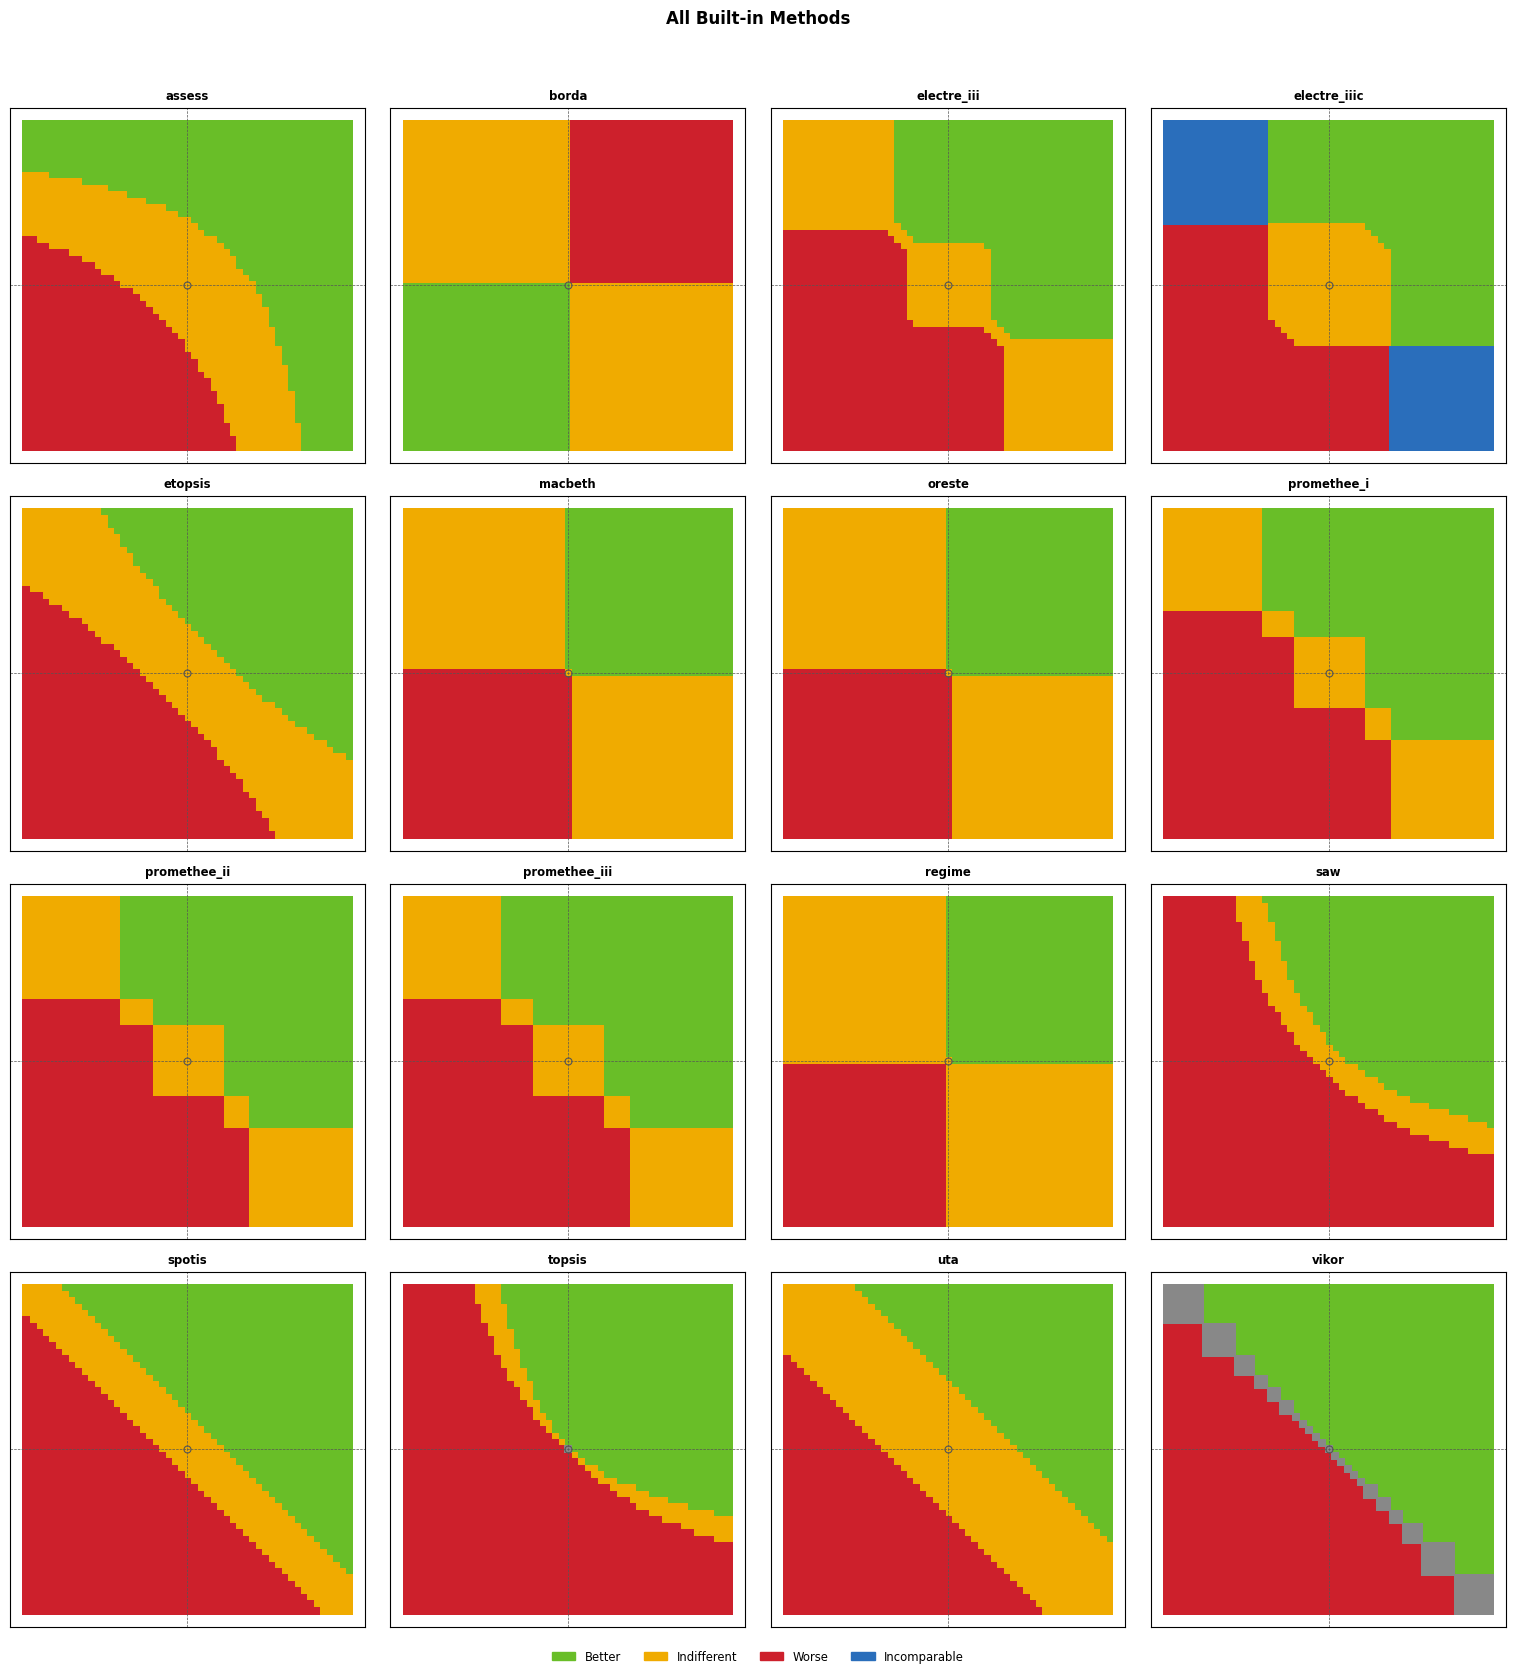

In [10]:
fig = plot_vista_comparison(results, ncols=4, title="All Built-in Methods", point_size=27)
fig.set_size_inches(16, 16)
fig.tight_layout()

Notice the gray areas in the last panel (VIKOR). Some ranking methods in pyDecision (usually due to normalization procedures) have numerical problems for certain pairs of alternatives (usually division by zero problems). These situations may well be translated to user-defined relations, such as incomparability or indifference in post processing of the ranking method outputs. However, the goal of vistas is to visualize and inform, therefore we leave these numerical/implementation problems visible to the user.